# Observation 0 - Amount violin plots by age bucket

This notebook renders violin plots inline for `Opportunity Amount USD` by fine age bucket,
with controlled views by key categorical variables (especially company-size fields).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
pd.options.display.max_rows = 200
pd.options.display.max_columns = 200


In [2]:
base_dir = Path.cwd().resolve()
candidate_roots = [base_dir, base_dir.parent, base_dir.parent.parent]
input_path = None

for root in candidate_roots:
    candidate = root / 'observation_0' / 'observation0_full_with_maturity.csv'
    if candidate.exists():
        input_path = candidate
        break

if input_path is None:
    raise FileNotFoundError('Could not locate observation0_full_with_maturity.csv from current working directory context')

df = pd.read_csv(input_path)
print(f'Loaded rows: {len(df):,}')
print(f'Input: {input_path}')


Loaded rows: 78,025
Input: /mnt/HC_Volume_104595655/home/goviedb/repos/mib/cars_analysis/observation_0/observation0_full_with_maturity.csv


In [3]:
fine_bins = [0, 15, 30, 45, 60, 75, 90, 120, np.inf]
fine_labels = ['0-15', '16-30', '31-45', '46-60', '61-75', '76-90', '91-120', '121+']

df['age_bucket_fine'] = pd.cut(
    df['Elapsed Days In Sales Stage'],
    bins=fine_bins,
    labels=fine_labels,
    right=True,
    include_lowest=True,
)

df['amount_usd'] = pd.to_numeric(df['Opportunity Amount USD'], errors='coerce')
df = df.dropna(subset=['amount_usd', 'age_bucket_fine']).copy()
df['amount_usd'] = df['amount_usd'].clip(lower=0)
df['amount_usd_log1p'] = np.log1p(df['amount_usd'])

for col in ['Client Size By Revenue (USD)', 'Client Size By Employee Count', 'Region', 'Route To Market', 'Opportunity Result']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown').astype(str)

df['age_bucket_fine'].value_counts().reindex(fine_labels, fill_value=0)


age_bucket_fine
0-15      11752
16-30     18370
31-45     13018
46-60     10814
61-75     11744
76-90     10649
91-120     1640
121+         38
Name: count, dtype: int64

In [4]:
def top_n_with_other(series: pd.Series, top_n: int = 6) -> pd.Series:
    top_values = series.value_counts(dropna=False).head(top_n).index
    return series.where(series.isin(top_values), 'Other')

def render_violin_plot(data: pd.DataFrame, x: str, y: str, title: str, order=None):
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.violinplot(data=data, x=x, y=y, order=order, inner='quartile', cut=0, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Age bucket')
    ax.set_ylabel('Opportunity Amount USD (log1p)')
    fig.tight_layout()
    plt.show()

def render_controlled_violin_grid(data: pd.DataFrame, control_col: str, top_n: int = 6, order=None):
    local = data.copy()
    local['control_group'] = top_n_with_other(local[control_col], top_n=top_n)
    groups = local['control_group'].value_counts().index.tolist()

    n_groups = len(groups)
    ncols = 2
    nrows = int(np.ceil(n_groups / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4.3 * nrows), sharey=True)
    axes = np.atleast_1d(axes).ravel()

    for idx, grp in enumerate(groups):
        ax = axes[idx]
        subset = local[local['control_group'] == grp]
        sns.violinplot(data=subset, x='age_bucket_fine', y='amount_usd_log1p', order=order, inner='quartile', cut=0, ax=ax)
        ax.set_title(f'{control_col}: {grp} (n={len(subset):,})')
        ax.set_xlabel('Age bucket')
        ax.set_ylabel('Opportunity Amount USD (log1p)' if idx % ncols == 0 else '')

    for j in range(n_groups, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f'Amount distribution by age bucket, controlled by {control_col}', y=1.01)
    fig.tight_layout()
    plt.show()

    summary = (
        local.groupby(['control_group', 'age_bucket_fine'], observed=False)['amount_usd']
        .agg(n_rows='size', mean_amount='mean', median_amount='median', std_amount='std')
        .reset_index()
    )
    return summary


## Overall violin plot

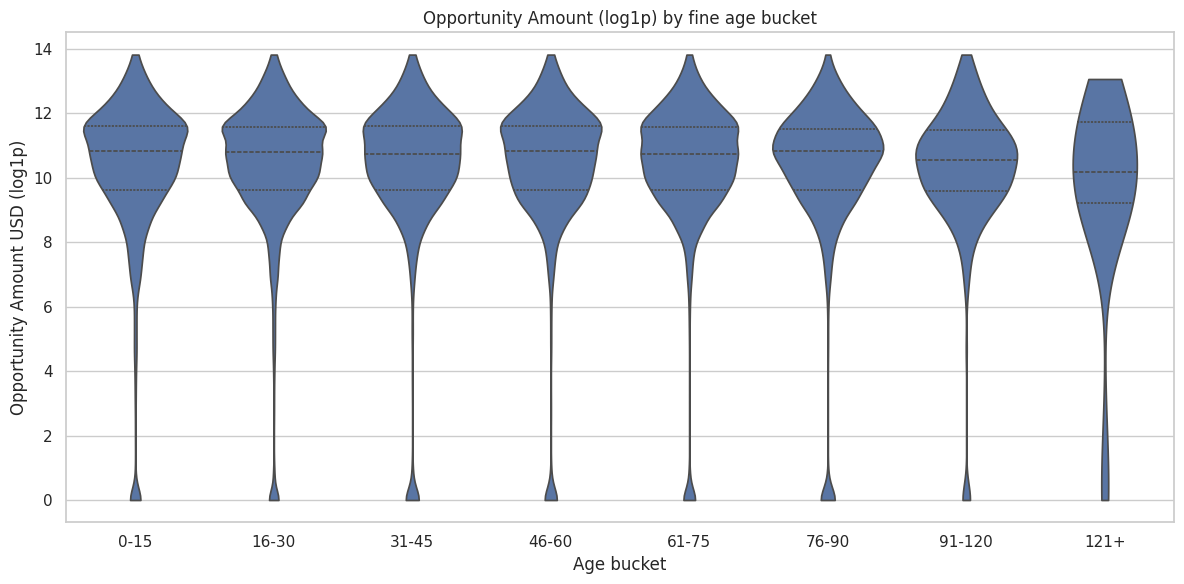

In [5]:
render_violin_plot(
    data=df,
    x='age_bucket_fine',
    y='amount_usd_log1p',
    title='Opportunity Amount (log1p) by fine age bucket',
    order=fine_labels,
)


## Controlled violin plots (company size first)

CONTROL VARIABLE: Client Size By Revenue (USD)


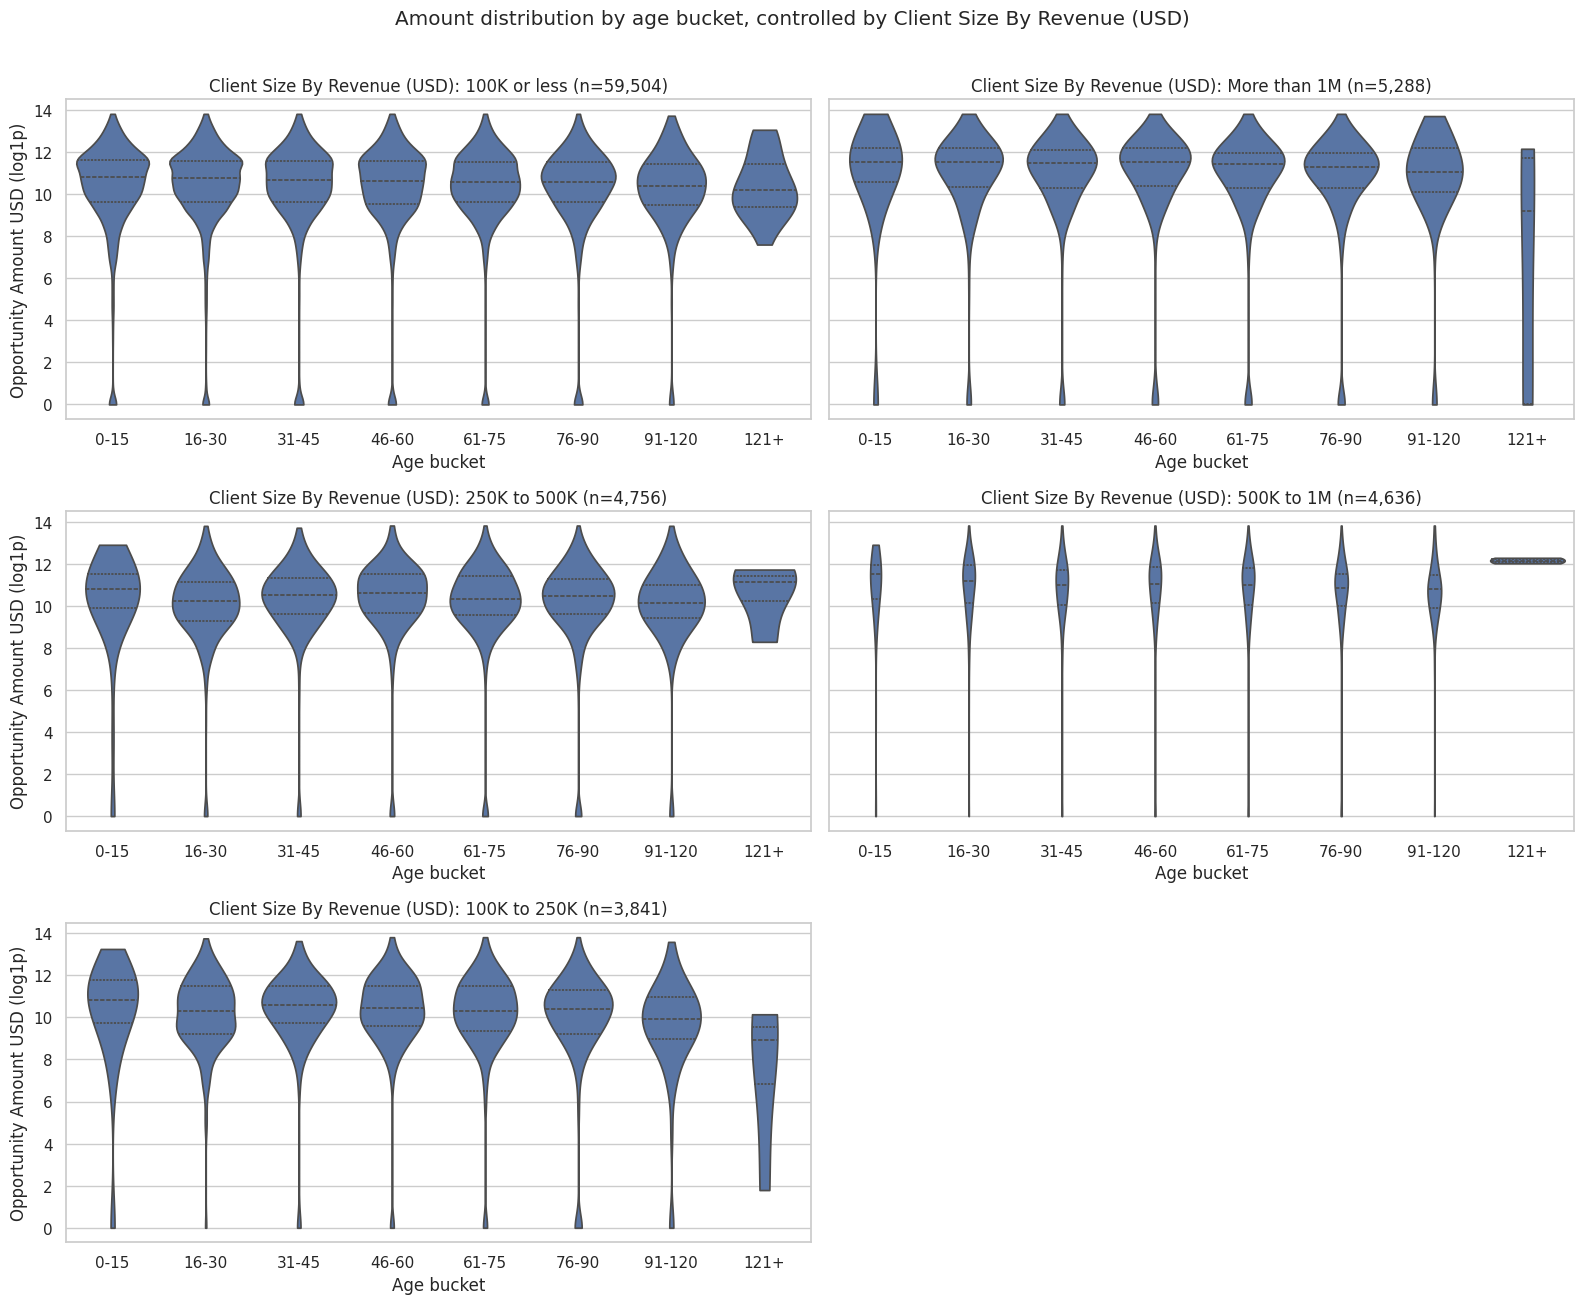

,control_group,age_bucket_fine,n_rows,mean_amount,median_amount,std_amount
0,100K or less,0-15,11540,93303.565858,50000.0,134940.358866
1,100K or less,16-30,16875,91739.787496,46511.0,133892.042281
2,100K or less,31-45,10917,90679.743153,43196.0,134402.949802
3,100K or less,46-60,7740,91047.109173,41425.0,136974.148922
4,100K or less,61-75,6218,83609.524606,39950.0,126086.748753
5,100K or less,76-90,5291,80384.018144,40000.0,119262.501798
6,100K or less,91-120,900,81743.166667,33006.0,130456.331968
7,100K or less,121+,23,91673.173913,27000.0,142614.038650
8,100K to 250K,0-15,38,90899.815789,50000.0,108763.504796
9,100K to 250K,16-30,328,74739.628049,30000.0,121346.723378


CONTROL VARIABLE: Client Size By Employee Count


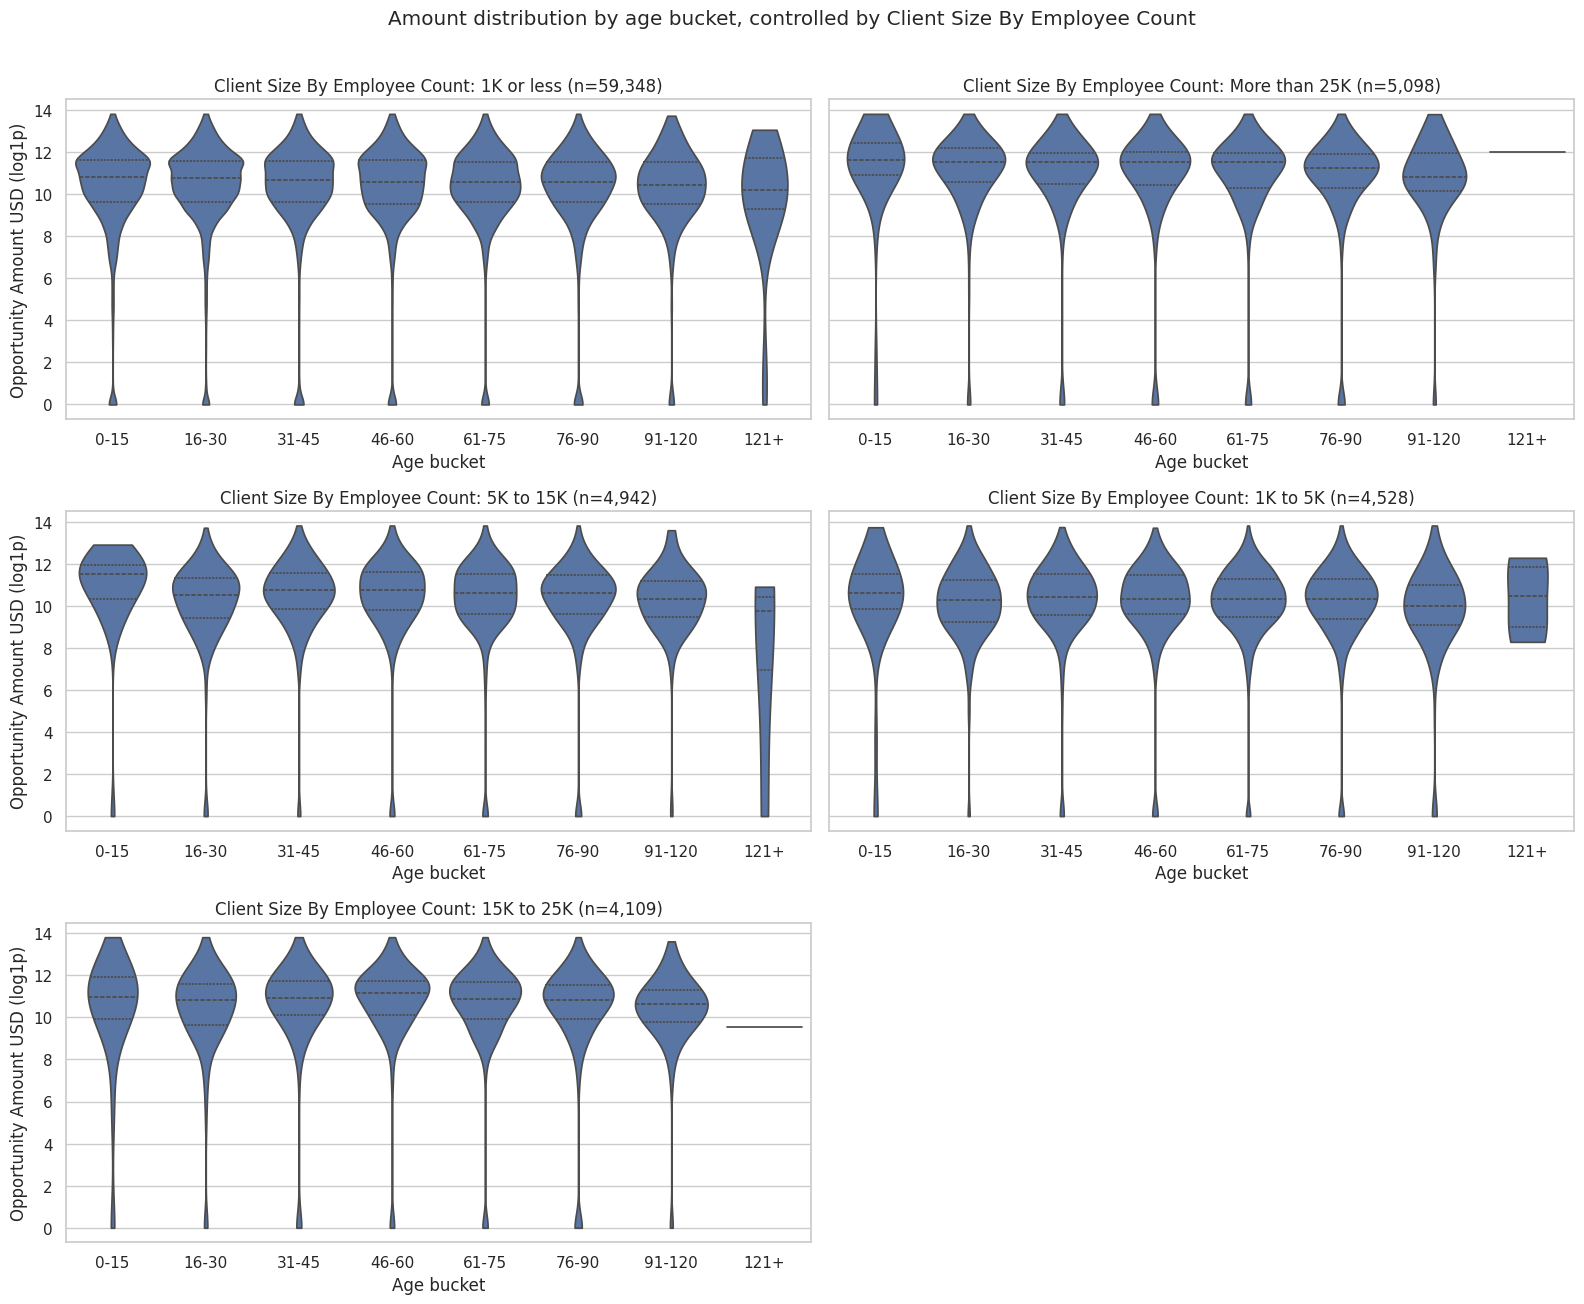

,control_group,age_bucket_fine,n_rows,mean_amount,median_amount,std_amount
0,15K to 25K,0-15,42,112537.738095,58500.0,166413.011038
1,15K to 25K,16-30,324,97202.567901,50000.0,146797.884065
2,15K to 25K,31-45,498,108696.644578,55658.5,146615.450062
3,15K to 25K,46-60,705,109811.619858,69767.0,136987.678223
4,15K to 25K,61-75,1250,100771.008800,52631.0,132191.322755
5,15K to 25K,76-90,1138,92181.948155,50000.0,118993.775333
6,15K to 25K,91-120,151,78459.370861,41822.0,122136.918793
7,15K to 25K,121+,1,13888.000000,13888.0,NaN
8,1K or less,0-15,11546,93070.628096,50000.0,134313.453505
9,1K or less,16-30,16861,92255.566455,47500.0,134603.471384


CONTROL VARIABLE: Region


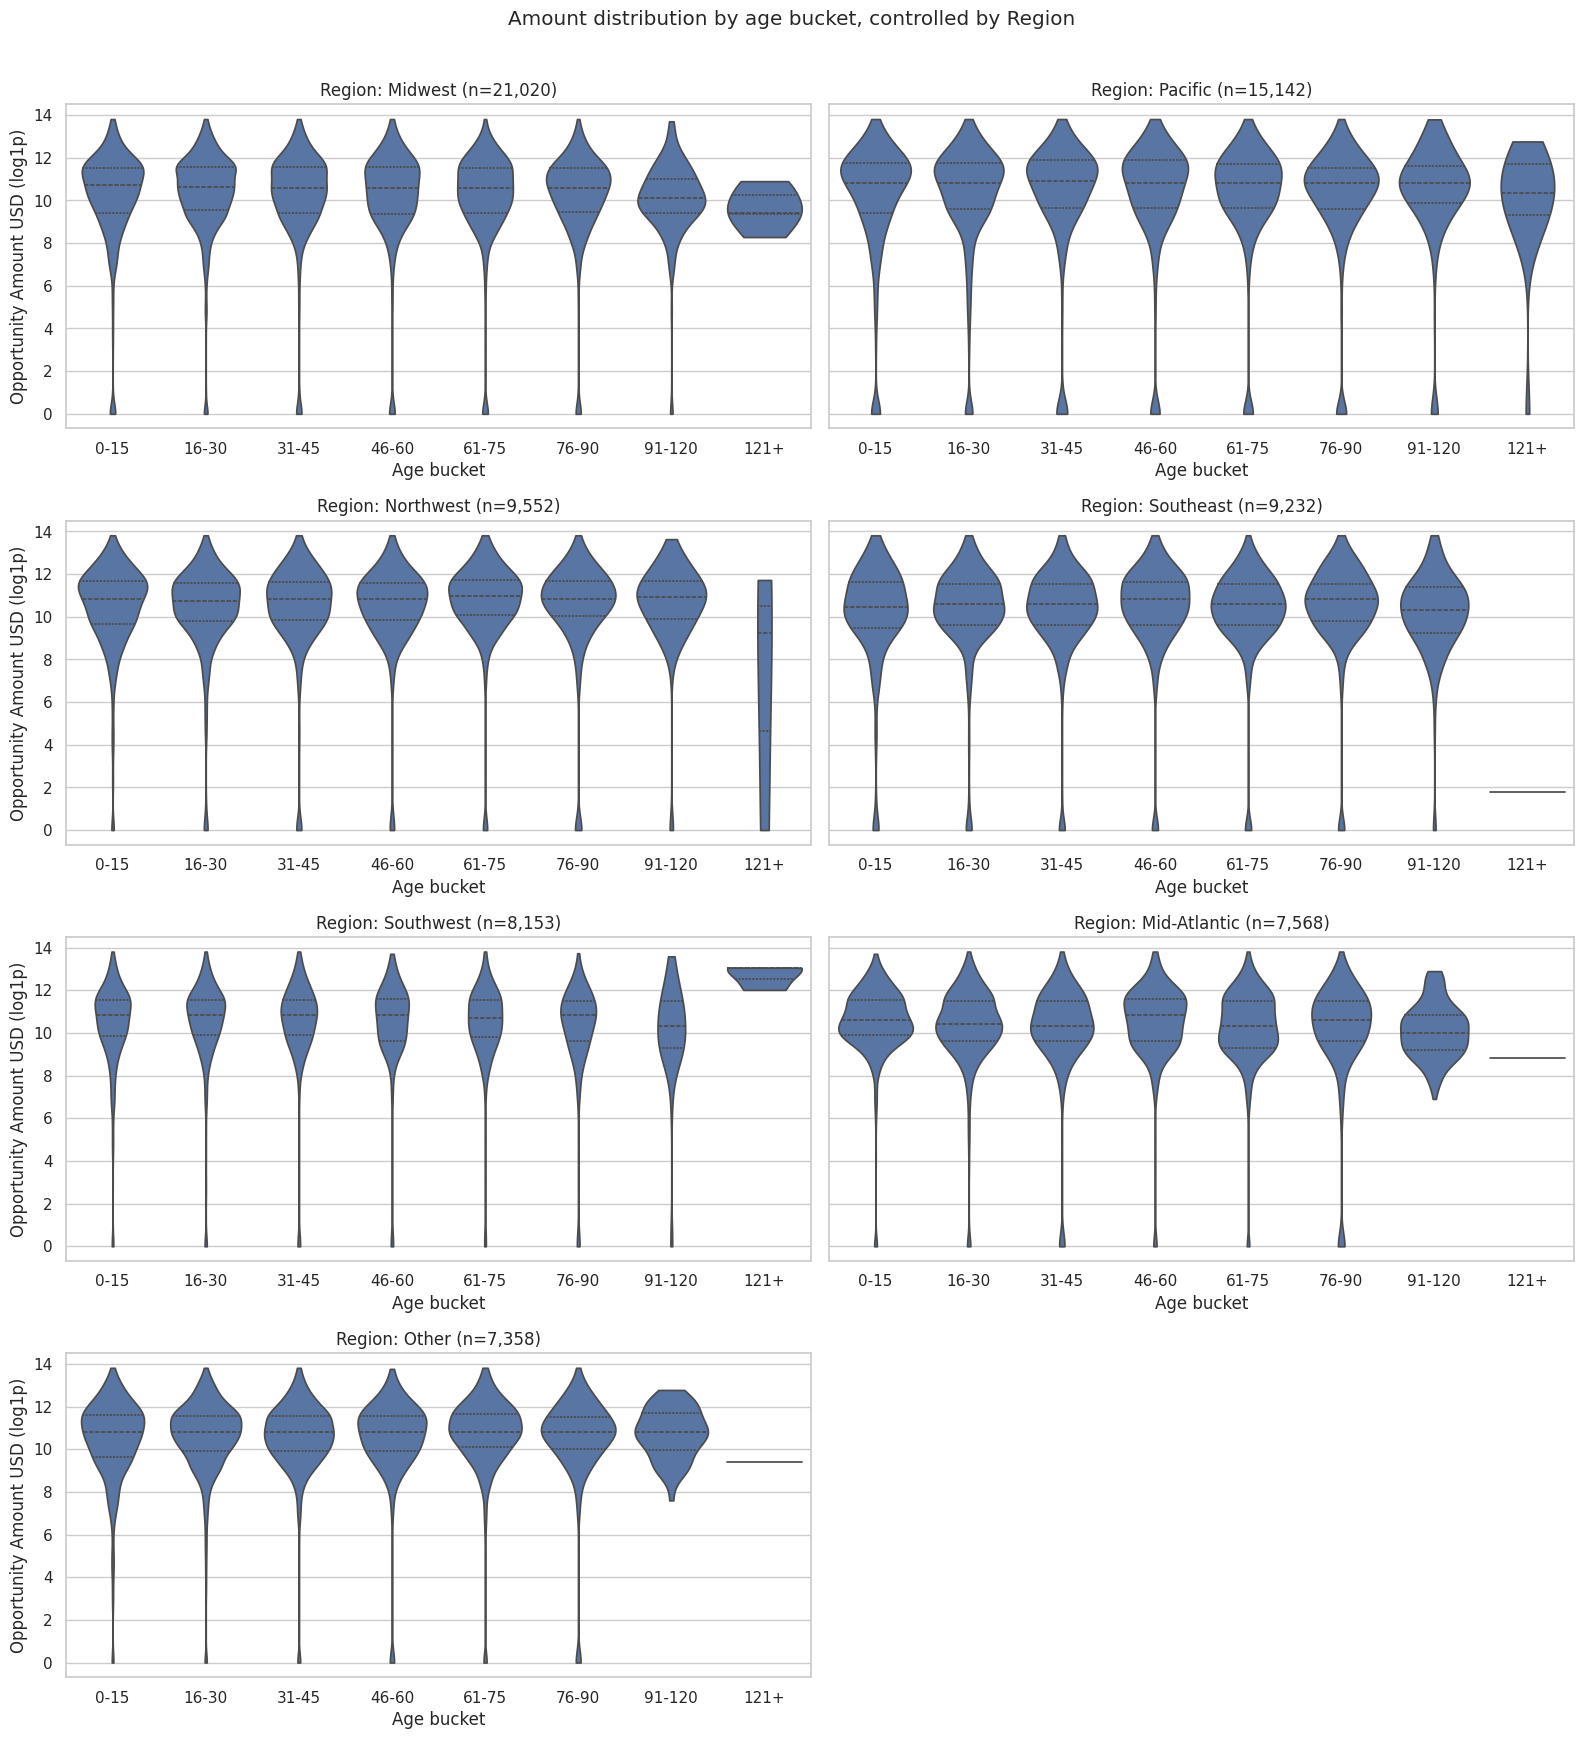

,control_group,age_bucket_fine,n_rows,mean_amount,median_amount,std_amount
0,Mid-Atlantic,0-15,1075,82592.287442,40000.0,112474.913731
1,Mid-Atlantic,16-30,1982,79801.411201,33000.0,120817.551854
2,Mid-Atlantic,31-45,1132,76906.199647,30000.0,115094.202134
3,Mid-Atlantic,46-60,992,90353.763105,50000.0,133120.665297
4,Mid-Atlantic,61-75,1081,76651.073080,30000.0,114430.123120
5,Mid-Atlantic,76-90,1164,80367.994845,41000.0,112056.620657
6,Mid-Atlantic,91-120,141,54250.219858,22000.0,81642.787079
7,Mid-Atlantic,121+,1,6745.000000,6745.0,NaN
8,Midwest,0-15,3077,85190.785180,45500.0,127938.566552
9,Midwest,16-30,4589,87030.014818,41261.0,128905.577914


CONTROL VARIABLE: Route To Market


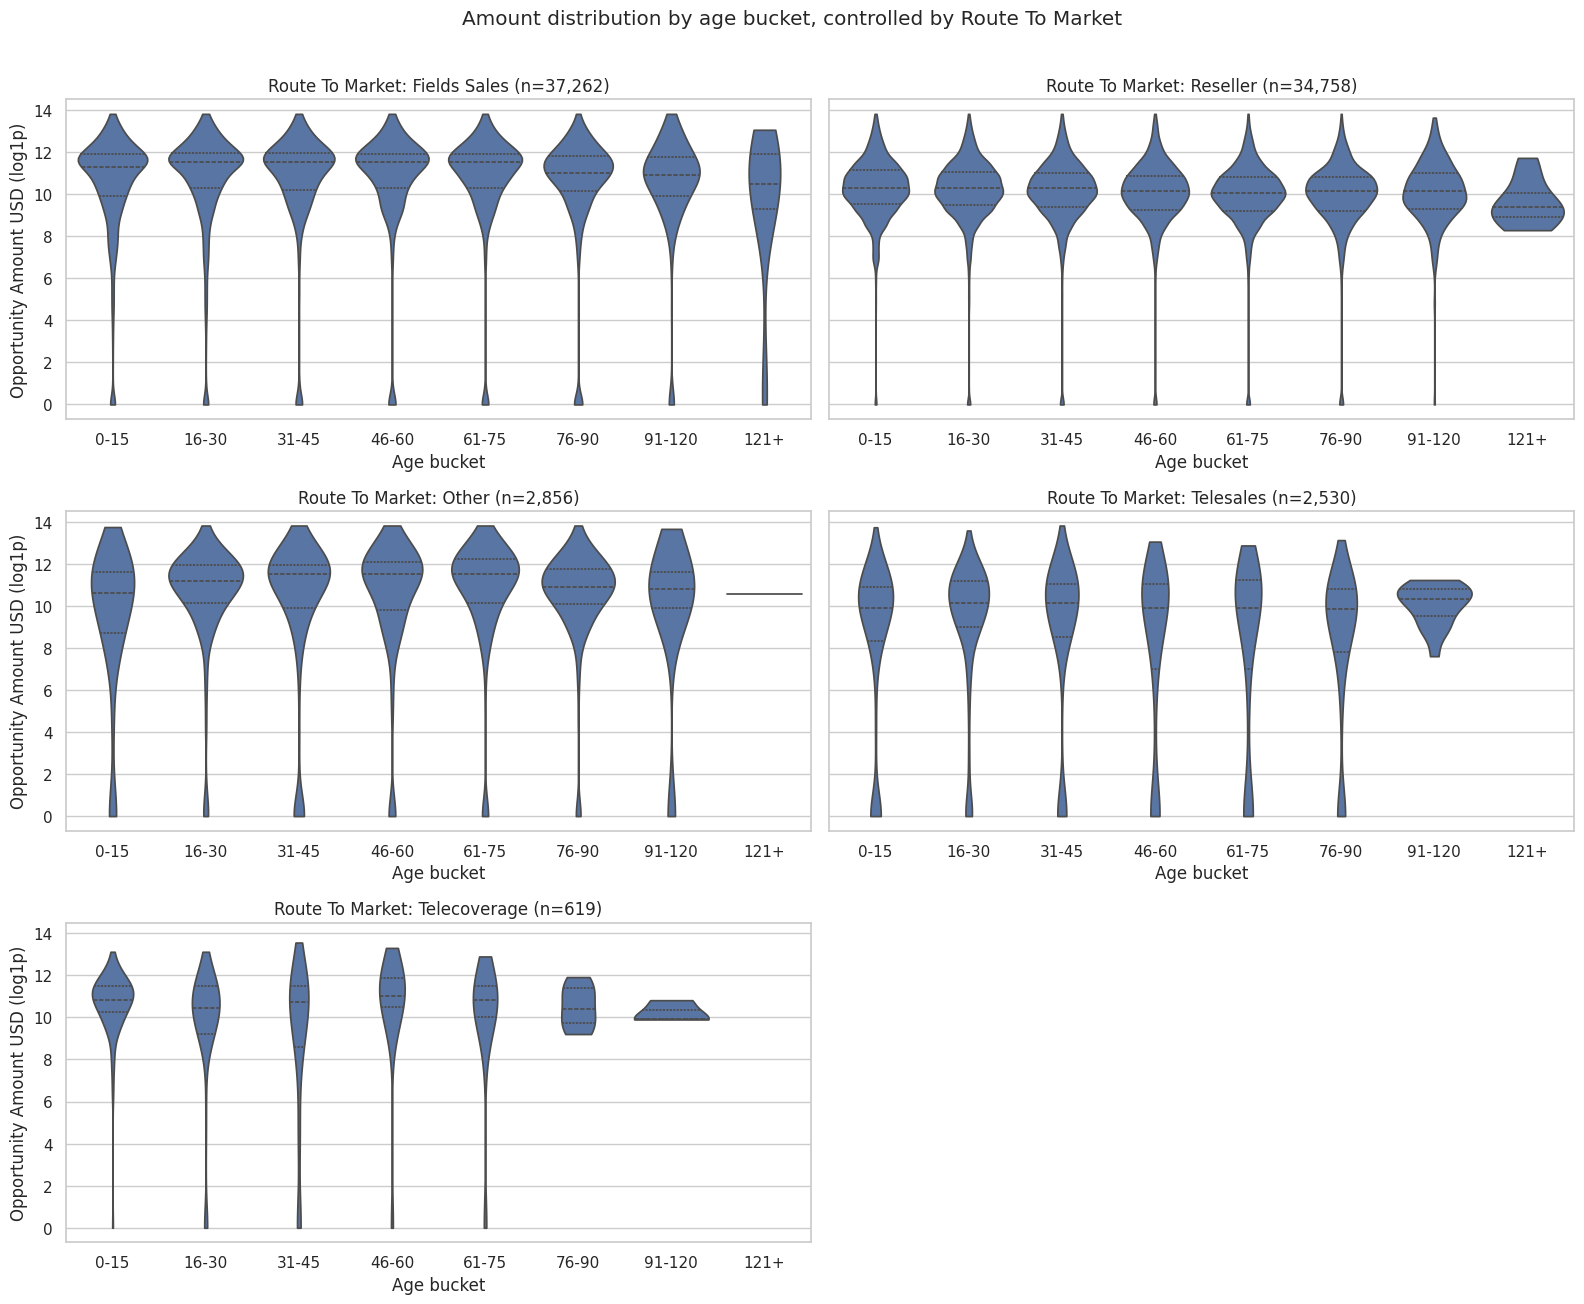

,control_group,age_bucket_fine,n_rows,mean_amount,median_amount,std_amount
0,Fields Sales,0-15,6269,120255.774446,80000.0,152996.576978
1,Fields Sales,16-30,7555,135251.645533,100000.0,163316.651558
2,Fields Sales,31-45,5446,130390.764965,100000.0,157208.592986
3,Fields Sales,46-60,5169,130560.595280,100000.0,155446.355898
4,Fields Sales,61-75,5834,125789.657011,100000.0,149857.847530
5,Fields Sales,76-90,6273,109841.135342,61349.0,136690.973312
6,Fields Sales,91-120,689,120645.066763,55000.0,173887.176888
7,Fields Sales,121+,27,104216.851852,36373.0,135538.750352
8,Other,0-15,118,99461.093220,40000.0,149642.043818
9,Other,16-30,594,113675.794613,72850.0,139343.333167


CONTROL VARIABLE: Opportunity Result


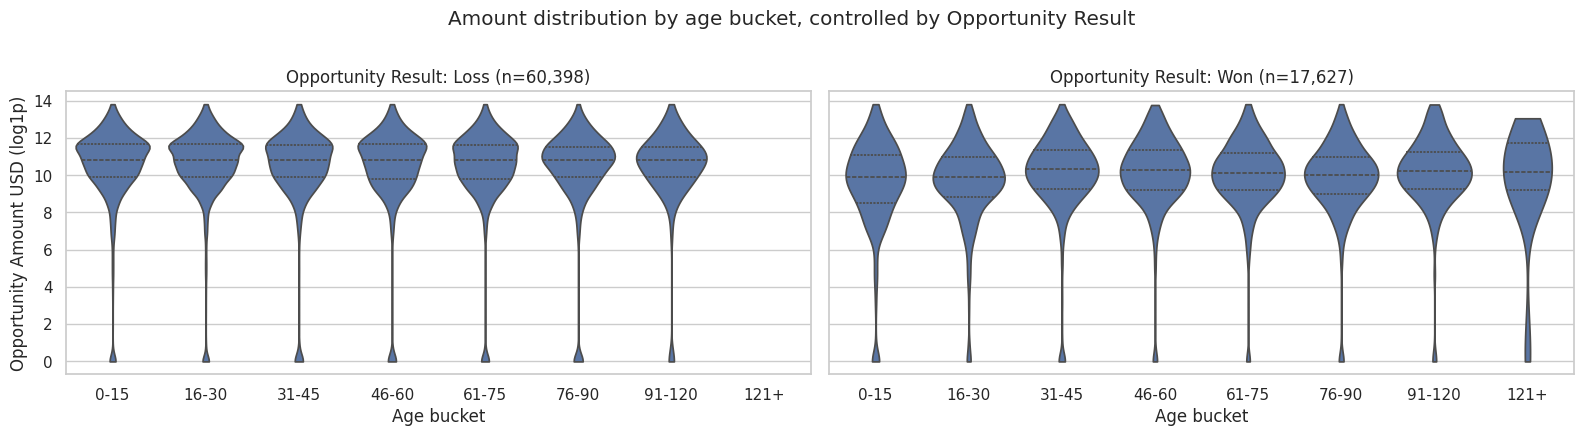

,control_group,age_bucket_fine,n_rows,mean_amount,median_amount,std_amount
0,Loss,0-15,8955,101542.193188,50000.0,135216.412984
1,Loss,16-30,14018,101183.056855,50000.0,135932.810394
2,Loss,31-45,9722,96791.708496,50000.0,136397.106250
3,Loss,46-60,8332,97464.847456,50000.0,133941.663160
4,Loss,61-75,9765,93377.876703,50000.0,129095.501115
5,Loss,76-90,8893,90796.767233,50000.0,122684.869854
6,Loss,91-120,713,89508.329593,50000.0,125352.517613
7,Loss,121+,0,NaN,NaN,NaN
8,Won,0-15,2797,69628.765821,20000.0,135351.847943
9,Won,16-30,4352,63943.875689,20000.0,126119.484124


In [6]:
control_vars = [
    'Client Size By Revenue (USD)',
    'Client Size By Employee Count',
    'Region',
    'Route To Market',
    'Opportunity Result',
]

controlled_summaries = {}

for control_col in control_vars:
    if control_col not in df.columns:
        continue
    print('=' * 100)
    print(f'CONTROL VARIABLE: {control_col}')
    summary_df = render_controlled_violin_grid(
        data=df,
        control_col=control_col,
        top_n=6,
        order=fine_labels,
    )
    controlled_summaries[control_col] = summary_df
    display(summary_df.head(20))


In [7]:
list(controlled_summaries.keys())

['Client Size By Revenue (USD)',
 'Client Size By Employee Count',
 'Region',
 'Route To Market',
 'Opportunity Result']